In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("car data.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [7]:
df['Transmission'].value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

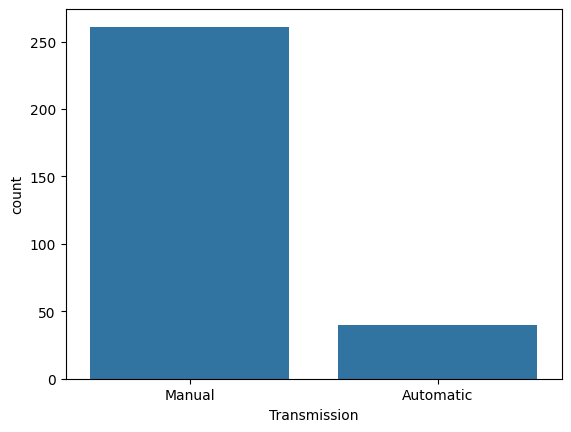

In [8]:
sns.countplot(x='Transmission',data=df)
plt.savefig("Transmission_hd.png",
            dpi=600,
            bbox_inches="tight")

In [9]:
df['Selling_Price'].value_counts()

Selling_Price
0.45     8
0.60     8
5.25     7
4.50     7
0.20     6
        ..
3.80     1
3.45     1
5.90     1
35.00    1
11.50    1
Name: count, Length: 156, dtype: int64

In [10]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

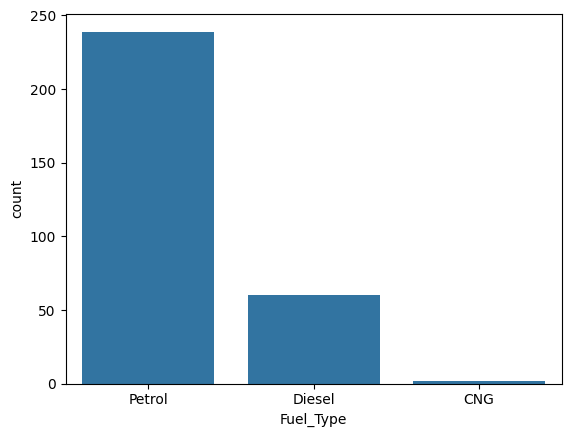

In [11]:
sns.countplot(x="Fuel_Type",data=df)
plt.savefig("Fuel_Type_hd.png",
            dpi=600,
            bbox_inches="tight")

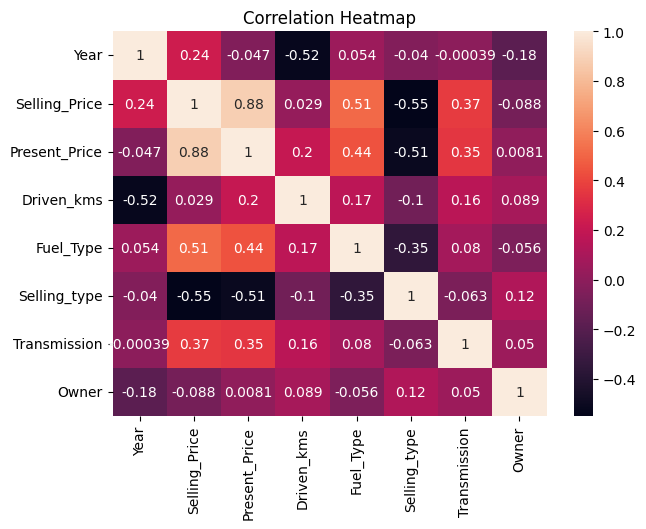

In [31]:
df1 = df.copy()

df1['Fuel_Type'] = df1['Fuel_Type'].map({
    'Petrol':0,
    'Diesel':1,
    'CNG':2
})

df1['Selling_type'] = df1['Selling_type'].map({
    'Dealer':0,
    'Individual':1
})

df1['Transmission'] = df1['Transmission'].map({
    'Manual':0,
    'Automatic':1
})

plt.figure(figsize=(7,5))

sns.heatmap(
    df1.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")

plt.savefig(
    "correlation_heatmap_hd.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [33]:
df['Selling_type'].value_counts()

Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

# Car Age Feature Create

In [36]:
df['Current_Year'] = 2026

df['Car_Age'] = df['Current_Year'] - df['Year']

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Current_Year,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,2026,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,2026,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2026,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,2026,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,2026,12


# Unnecessary Columns Remove

In [39]:
df.drop(['Car_Name','Year','Current_Year'],
        axis=1,
        inplace=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


# Convert Text Data into Numbers

In [42]:
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


# Features & Target

In [45]:
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

# Train-Test Split

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model Train

In [53]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# Prediction

In [56]:
predictions = model.predict(X_test)

predictions[:10]

array([ 0.4438, 10.9098,  4.9315,  0.2159,  7.7988,  6.2535,  1.1065,
        0.5876,  0.469 ,  6.896 ])

# Accuracy Check

In [59]:
from sklearn.metrics import r2_score

score = r2_score(
    y_test,
    predictions
)

print("R2 Score:", score)

R2 Score: 0.9594566919773236


# Prediction Graph

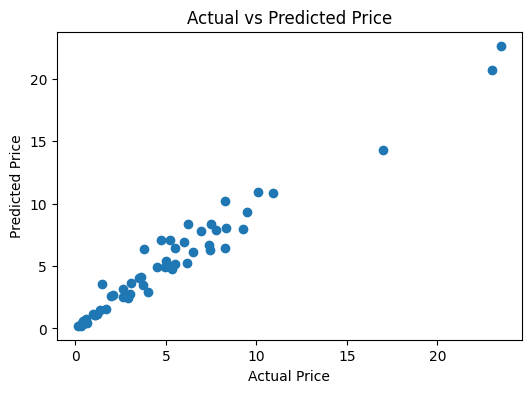

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.savefig(
    "actual_vs_predicted_hd.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()